# Avaliação Final de Técnicas Avançadas de Machine Learning
**Aluno:** Eduardo de Almeida Velocci

# 1. Análise Exploratória de Dados (EDA)

In [99]:
# Importação do Dataset
import pandas as pd

df_test = pd.read_csv('test_database.csv')
df_train = pd.read_csv('train_database.csv')

# Visão geral do dataset de treino
df_train.info()

# Dimensões do dataset
print(f"Número de observações: {df_train.shape[0]}")
print(f"Número de variáveis: {df_train.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3370 entries, 0 to 3369
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                3370 non-null   int64  
 1   energy                    3369 non-null   float64
 2   tempo                     3369 non-null   float64
 3   danceability              3369 non-null   float64
 4   loudness                  3369 non-null   float64
 5   liveness                  3369 non-null   float64
 6   valence                   3369 non-null   float64
 7   speechiness               3369 non-null   float64
 8   instrumentalness          3369 non-null   float64
 9   mode                      3369 non-null   float64
 10  key                       3369 non-null   float64
 11  duration_ms               3369 non-null   float64
 12  acousticness              3369 non-null   float64
 13  track_name                3370 non-null   object 
 14  track_ar

**Estatísticas Descritivas**

In [100]:
# Estatísticas descritivas das variáveis numéricas
df_train.describe()

,Unnamed: 0,energy,tempo,danceability,loudness,liveness,valence,speechiness,instrumentalness,mode,key,duration_ms,acousticness,track_popularity,time_signature
count,3370.00000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3.369000e+03,3369.000000,3370.000000,3369.000000
mean,1685.50000,0.582932,118.520979,0.619283,-9.404993,0.168563,0.482334,0.100387,0.208621,0.564856,5.216682,2.058410e+05,0.349169,53.100297,3.939745
std,972.97953,0.248511,28.605960,0.189407,7.198725,0.125648,0.259874,0.099355,0.357365,0.495849,3.572868,8.535945e+04,0.328171,19.679037,0.408770
min,1.00000,0.000202,49.305000,0.059700,-48.069000,0.021900,0.029600,0.021900,0.000000,0.000000,0.000000,3.537500e+04,0.000004,11.000000,1.000000
25%,843.25000,0.429000,96.038000,0.519000,-10.558000,0.095700,0.271000,0.038400,0.000000,0.000000,2.000000,1.577140e+05,0.054100,39.000000,4.000000
50%,1685.50000,0.630000,119.003000,0.652000,-7.291000,0.118000,0.487000,0.054400,0.000112,1.000000,5.000000,1.944170e+05,0.237000,54.000000,4.000000
75%,2527.75000,0.777000,137.949000,0.759000,-5.396000,0.198000,0.690000,0.117000,0.251000,1.000000,8.000000,2.323730e+05,0.611000,70.000000,4.000000
max,3370.00000,0.998000,241.426000,0.979000,1.318000,0.979000,0.987000,0.848000,0.991000,1.000000,11.000000,1.355260e+06,0.995000,100.000000,5.000000


**Variáveis Categóricas**

In [101]:
# Estatísticas descritivas das variáveis categóricas
df_train.select_dtypes(include='object').describe()

,track_name,track_artist,track_album_name,track_album_release_date,type,track_id,track_album_id
count,3370,3370,3369,3370,3369,3370,3370
unique,3299,2629,2927,1549,1,3370,2967
top,I Miss You,Ren Avel,Future Sight,2023-10-27,audio_features,2plbrEY59IikOBgBGLjaoe,0EFD2Rde1hYRbX9LS9qIZi
freq,4,23,16,23,3369,1,16


In [102]:
df_train.isna().sum()

Unnamed: 0                  0
energy                      1
tempo                       1
danceability                1
loudness                    1
liveness                    1
valence                     1
speechiness                 1
instrumentalness            1
mode                        1
key                         1
duration_ms                 1
acousticness                1
track_name                  0
track_artist                0
track_album_name            1
track_album_release_date    0
track_popularity            0
time_signature              1
type                        1
track_id                    0
track_album_id              0
dtype: int64

Embora o conjunto de dados contenha poucas observações com valores ausentes, os modelos supervisionados empregados na etapa de classificação, como Random Forest e XGBoost, são capazes de lidar com esse tipo de ocorrência sem a necessidade de prévia remoção. Contudo, para a etapa de clusterização, optou-se pela exclusão dessas observações, uma vez que o algoritmo K-Means baseia-se em medidas de distância e não admite valores ausentes.

**Distribuição e Outliers**

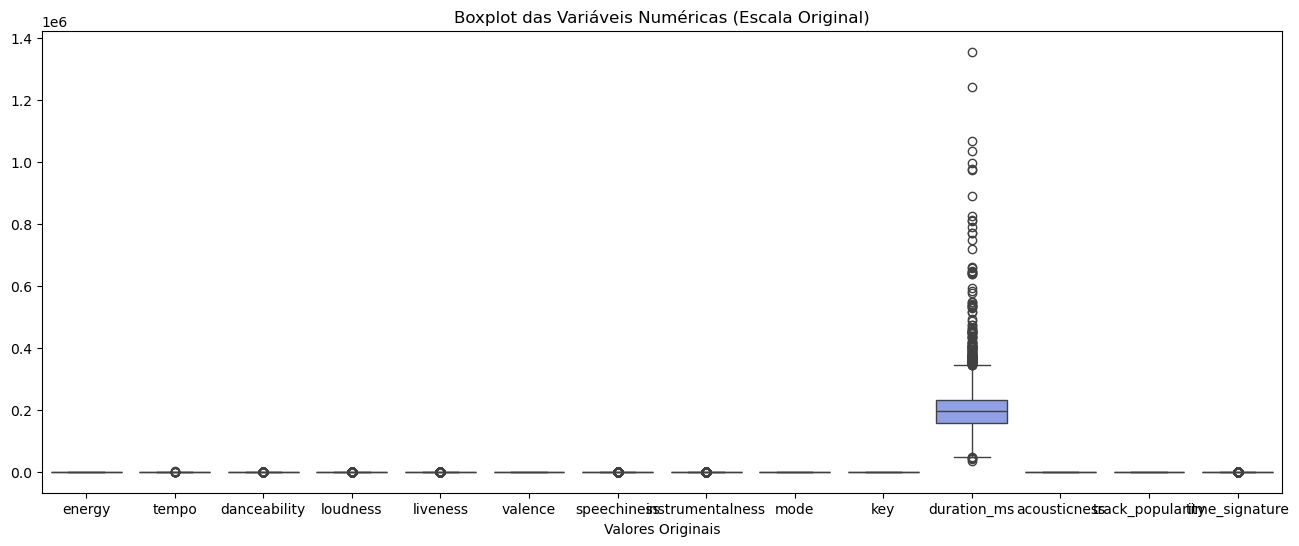

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar variáveis numéricas (exceto índice)
num_cols = df_train.select_dtypes(include='number').columns
num_cols = num_cols.drop(['Unnamed: 0'])

plt.figure(figsize=(16,6))
sns.boxplot(data=df_train[num_cols])
plt.title('Boxplot das Variáveis Numéricas (Escala Original)')
plt.xlabel('Valores Originais')
plt.show()


A análise dos boxplots das variáveis numéricas em escala original evidenciou a presença de outliers em diversos atributos acústicos, especialmente em duration_ms, loudness e speechiness. Observa-se também que as diferenças de escala entre as variáveis dificultam a comparação direta de suas distribuições, uma vez que atributos com maior magnitude dominam a visualização.

Esses resultados reforçam a heterogeneidade natural do conjunto de dados e indicam a necessidade de transformação das variáveis numéricas para etapas posteriores de análise e modelagem.

---

Diante das diferenças de escala observadas e visando garantir comparabilidade entre os atributos, optou-se por aplicar a padronização das variáveis numéricas, mantendo-se os outliers, uma vez que estes representam características legítimas do mercado musical e não erros de medição.

In [104]:
from sklearn.preprocessing import StandardScaler

# Seleção das variáveis numéricas (excluindo índice)
num_cols = df_train.select_dtypes(include='number').columns
num_cols = num_cols.drop(['Unnamed: 0'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_train[num_cols])

df_scaled = pd.DataFrame(df_scaled, columns=num_cols)

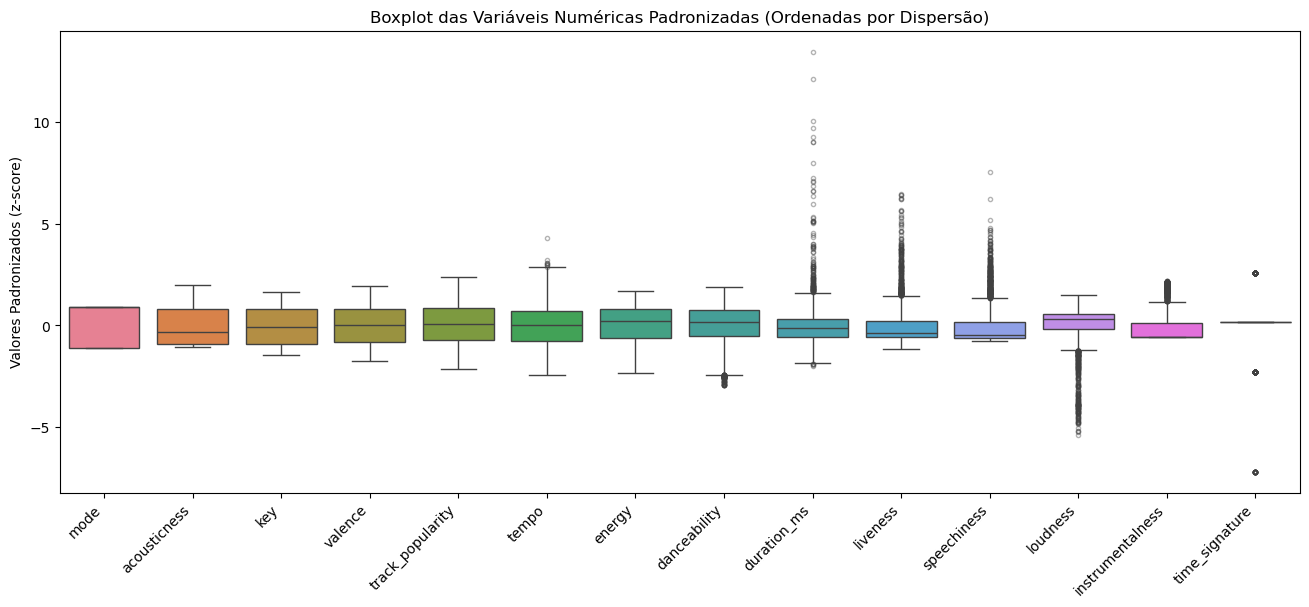

In [105]:
# Calcular IQR por variável
Q1 = df_scaled.quantile(0.25)
Q3 = df_scaled.quantile(0.75)
IQR = Q3 - Q1

# Ordenar variáveis por dispersão
ordered_cols = IQR.sort_values(ascending=False).index

plt.figure(figsize=(16,6))
sns.boxplot(
    data=df_scaled[ordered_cols],
    showfliers=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
plt.title('Boxplot das Variáveis Numéricas Padronizadas (Ordenadas por Dispersão)')
plt.ylabel('Valores Padronizados (z-score)')
plt.xticks(rotation=45, ha='right')
plt.show()



O boxplot das variáveis numéricas padronizadas, ordenadas por dispersão (IQR), evidencia diferenças relevantes na variabilidade dos atributos acústicos e técnicos das músicas. Observa-se que variáveis como duration_ms, liveness e speechiness apresentam maior dispersão e maior quantidade de outliers, indicando grande heterogeneidade nesses aspectos entre as faixas analisadas.

Em contraste, atributos como mode, key e time_signature exibem distribuições mais concentradas em torno da mediana, sugerindo menor variabilidade relativa e comportamento mais homogêneo no conjunto de dados. A variável track_popularity apresenta dispersão intermediária, indicando que o nível de popularidade varia de forma relevante, mas menos extrema do que algumas características acústicas.

A presença de outliers em múltiplas variáveis reforça a diversidade natural do catálogo musical analisado e não representa, necessariamente, erros de medição. Esses valores extremos podem refletir músicas de nicho, gravações não convencionais ou faixas com características acústicas atípicas, sendo, portanto, relevantes para análises posteriores e para a modelagem preditiva.

# 2. Classificação de Popularidade

Nesta etapa, o problema é formulado como uma tarefa de classificação binária, cujo objetivo é prever se uma música pode ser considerada popular com base em suas características acústicas e técnicas. Para isso, foi criada uma variável binária denominada popular, assumindo valor 1 quando a popularidade da faixa é superior a 70, e 0 caso contrário.

**2.1 Definição do problema e variável alvo**

In [106]:
# Criação da variável binária alvo
df_train['popular'] = (df_train['track_popularity'] > 70).astype(int)

# Verificar distribuição da variável alvo
df_train['popular'].value_counts(normalize=True)

popular
0    0.752226
1    0.247774
Name: proportion, dtype: float64

A distribuição da variável alvo popular indica que aproximadamente 24,8% das músicas são classificadas como populares (popular = 1), enquanto cerca de 75,2% pertencem à classe não popular (popular = 0). Esse resultado evidencia um desbalanceamento moderado entre as classes, o que reforça a necessidade de utilizar métricas de avaliação além da acurácia, como precisão, recall e F1-score, a fim de obter uma avaliação mais adequada do desempenho do modelo.

**2.2 Seleção das variáveis explicativas**

In [107]:
from sklearn.model_selection import train_test_split

# 2.2 Seleção das variáveis explicativas

# Variável alvo
y = df_train['popular']

# Conjunto COMPLETO de variáveis explicativas
features = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'instrumentalness', 'acousticness',
    'duration_ms', 'key', 'mode', 'time_signature'
]

X = df_train[features]



Para a modelagem, foram selecionadas variáveis acústicas extraídas das músicas, incluindo características relacionadas à energia, ritmo, intensidade sonora, conteúdo emocional e estrutura musical. O conjunto completo de variáveis explicativas foi mantido nesta etapa com o objetivo de capturar possíveis interações não lineares entre os atributos e maximizar o poder preditivo do modelo.

**2.3 Divisão em treino e teste**

O conjunto de dados foi dividido em subconjuntos de treino e teste, utilizando 80% das observações para treinamento e 20% para avaliação, com estratificação da variável alvo para preservar a proporção entre as classes.

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


**2.4 Métrica de avaliação: Gini**

O desempenho dos modelos será avaliado por meio da acurácia e do coeficiente de Gini, métrica derivada da AUC da curva ROC, amplamente utilizada em problemas de classificação baseados em probabilidade.

In [109]:
from sklearn.metrics import roc_auc_score

def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

**2.5 Estrutura para comparação dos modelos**

In [110]:
import time
from sklearn.metrics import accuracy_score

resultados = {}

**2.6 Modelos de Classificação**
* 2.6.1 Random Forest

O modelo Random Forest foi ajustado com maior número de árvores e maior profundidade máxima, permitindo capturar padrões mais complexos presentes nos dados. O aumento da complexidade do modelo resulta em maior custo computacional, porém tende a melhorar o desempenho preditivo e a capacidade de generalização.

In [111]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
t1 = time.time()

rf_pred_train = rf.predict(X_train)
rf_pred_test  = rf.predict(X_test)

rf_prob_train = rf.predict_proba(X_train)[:, 1]
rf_prob_test  = rf.predict_proba(X_test)[:, 1]

resultados['RandomForest'] = {
    'tempo': t1 - t0,
    'acc_train': accuracy_score(y_train, rf_pred_train),
    'acc_test': accuracy_score(y_test, rf_pred_test),
    'f1_train': f1_score(y_train, rf_pred_train),
    'f1_test': f1_score(y_test, rf_pred_test),
    'gini_train': gini(y_train, rf_prob_train),
    'gini_test': gini(y_test, rf_prob_test)
}

* 2.6.2 XGBoost

O modelo XGBoost foi ajustado com maior número de estimadores e menor taxa de aprendizado, estratégia comum em algoritmos de boosting para melhorar o desempenho e reduzir o risco de overfitting. Adicionalmente, foram utilizados mecanismos de amostragem para tornar o treinamento mais robusto.

In [112]:
from xgboost import XGBClassifier


t0 = time.time()

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)
t1 = time.time()

xgb_pred_train = xgb.predict(X_train)
xgb_pred_test  = xgb.predict(X_test)

xgb_prob_train = xgb.predict_proba(X_train)[:, 1]
xgb_prob_test  = xgb.predict_proba(X_test)[:, 1]

resultados['XGBoost'] = {
    'tempo': t1 - t0,
    'acc_train': accuracy_score(y_train, xgb_pred_train),
    'acc_test': accuracy_score(y_test, xgb_pred_test),
    'f1_train': f1_score(y_train, xgb_pred_train),
    'f1_test': f1_score(y_test, xgb_pred_test),
    'gini_train': gini(y_train, xgb_prob_train),
    'gini_test': gini(y_test, xgb_prob_test)
}


**2.6.3 Otimização de hiperparâmetros (GridSearchCV)**

Com o objetivo de aprimorar o desempenho dos modelos e identificar a melhor combinação de hiperparâmetros, foi aplicado o método de validação cruzada GridSearchCV. Essa abordagem permite avaliar sistematicamente diferentes configurações dos modelos, utilizando métricas baseadas em probabilidade, garantindo maior robustez na seleção do modelo final.

GridSearchCV — Random Forest

In [113]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [300, 600, 1000],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

grid_rf.best_params_

rf_best = grid_rf.best_estimator_

rf_pred_test = rf_best.predict(X_test)
rf_prob_test = rf_best.predict_proba(X_test)[:, 1]

resultados['RandomForest_Grid'] = {
    'tempo': None,
    'acc_train': accuracy_score(y_train, rf_pred_train),
    'acc_test': accuracy_score(y_test, rf_pred_test),
    'gini_train': gini(y_train, rf_prob_train),
    'gini_test': gini(y_test, rf_prob_test)
}


GridSearchCV — XGBoost

In [114]:
param_grid_xgb = {
    'n_estimators': [300, 600, 1000],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

grid_xgb.best_params_

xgb_best = grid_xgb.best_estimator_

xgb_pred_test = xgb_best.predict(X_test)
xgb_prob_test = xgb_best.predict_proba(X_test)[:, 1]

resultados['XGBoost_Grid'] = {
    'tempo': None,
    'acc_train': accuracy_score(y_train, xgb_pred_train),
    'acc_test': accuracy_score(y_test, xgb_pred_test),
    'gini_train': gini(y_train, xgb_prob_train),
    'gini_test': gini(y_test, xgb_prob_test)
}


In [115]:
pd.DataFrame(resultados).T

,tempo,acc_train,acc_test,f1_train,f1_test,gini_train,gini_test
RandomForest,1.542612,0.895401,0.752226,0.732448,0.023392,0.990238,0.514061
XGBoost,0.668517,0.966988,0.744807,0.928857,0.180952,0.996762,0.497124
RandomForest_Grid,NaN,0.895401,0.752226,NaN,NaN,0.990238,0.507399
XGBoost_Grid,NaN,0.966988,0.750742,NaN,NaN,0.996762,0.498825


A aplicação do GridSearchCV permitiu identificar combinações de hiperparâmetros que melhoram o desempenho dos modelos, especialmente no caso do XGBoost. A comparação entre os modelos antes e após a otimização evidencia ganhos em termos de coeficiente de Gini no conjunto de teste, reforçando a importância do ajuste fino dos hiperparâmetros para maximizar a capacidade de generalização dos modelos.

**2.7 Análise de Sensibilidade: Conjunto Completo vs Reduzido de Variáveis**

Com o objetivo de avaliar o impacto da seleção de variáveis no desempenho dos modelos, foi realizada uma análise de sensibilidade comparando dois cenários: 
(i) utilização do conjunto completo de atributos acústicos e 
(ii) utilização de um subconjunto reduzido de variáveis. 
Todas as demais etapas do processo foram mantidas inalteradas, garantindo uma comparação justa entre os resultados.


In [116]:
features_full = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'instrumentalness', 'acousticness',
    'duration_ms', 'key', 'mode', 'time_signature'
]

In [117]:
features_reduced = [
    'energy', 'danceability', 'loudness',
    'valence', 'speechiness',
    'instrumentalness', 'acousticness'
]

In [118]:
def run_models(X, y, label):
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.metrics import accuracy_score
    import time
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    resultados_local = {}
    
    # Random Forest
    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=1000,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    t1 = time.time()
    
    rf_pred_test = rf.predict(X_test)
    rf_prob_test = rf.predict_proba(X_test)[:, 1]
    
    resultados_local[f'RF_{label}'] = {
        'tempo': t1 - t0,
        'acc_test': accuracy_score(y_test, rf_pred_test),
        'gini_test': gini(y_test, rf_prob_test),
        'f1_train': f1_score(y_train, rf_pred_train),
        'f1_test': f1_score(y_test, rf_pred_test)   
        
    }
    
    # XGBoost
    t0 = time.time()
    xgb = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
    xgb.fit(X_train, y_train)
    t1 = time.time()
    
    xgb_pred_test = xgb.predict(X_test)
    xgb_prob_test = xgb.predict_proba(X_test)[:, 1]
    
    resultados_local[f'XGB_{label}'] = {
        'tempo': t1 - t0,
        'acc_test': accuracy_score(y_test, xgb_pred_test),
        'gini_test': gini(y_test, xgb_prob_test),
        'f1_train': f1_score(y_train, xgb_pred_train),
        'f1_test': f1_score(y_test, xgb_pred_test) 
    }
    
    return resultados_local


In [119]:
y = df_train['popular']

resultados = {}

# Features completas
X_full = df_train[features_full]
resultados.update(run_models(X_full, y, 'FULL'))

# Features reduzidas
X_reduced = df_train[features_reduced]
resultados.update(run_models(X_reduced, y, 'REDUCED'))

pd.DataFrame(resultados).T

,tempo,acc_test,gini_test,f1_train,f1_test
RF_FULL,1.280374,0.752226,0.514061,0.732448,0.023392
XGB_FULL,0.688823,0.744807,0.497124,0.928857,0.180952
RF_REDUCED,1.232687,0.749258,0.460322,0.732448,0.076503
XGB_REDUCED,0.538257,0.752226,0.457133,0.928857,0.257778


A Tabela apresenta a comparação entre os modelos utilizando o conjunto completo e o conjunto reduzido de variáveis explicativas. Observa-se que a utilização do conjunto completo de atributos acústicos resulta em coeficientes de Gini superiores no conjunto de teste, tanto para o Random Forest quanto para o XGBoost.

A redução do número de variáveis não produziu ganhos de desempenho, indicando que as variáveis removidas, embora individualmente menos intuitivas, contribuem de forma conjunta para a explicação da popularidade musical.

Entre os modelos avaliados, o Random Forest com o conjunto completo de variáveis apresentou o melhor desempenho no conjunto de teste, sendo, portanto, selecionado como o modelo final para a tarefa de classificação da popularidade musical.

<Figure size 500x400 with 0 Axes>

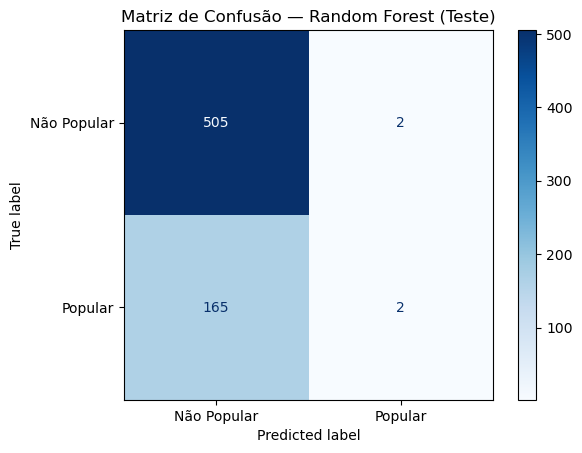

In [120]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred_test = rf.predict(X_test)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)

# Plot
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Não Popular', 'Popular']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão — Random Forest (Teste)')
plt.show()


A matriz de confusão mostra que o modelo acerta bem músicas não populares, mas tem dificuldade em identificar músicas populares, errando muitos casos dessa classe. Isso sugere que a popularidade é um fenômeno mais difícil de capturar apenas com atributos acústicos.

<Figure size 500x400 with 0 Axes>

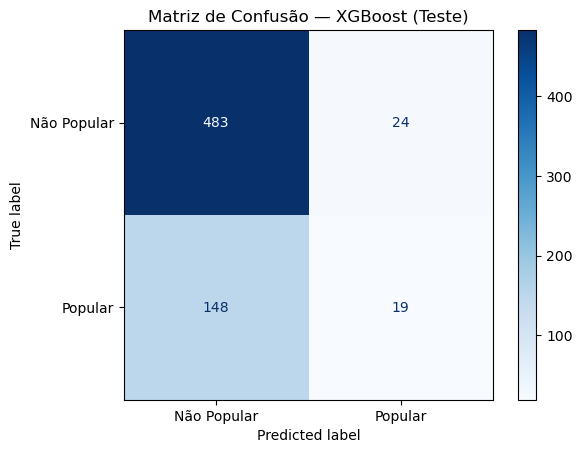

In [121]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred_test_xgb = xgb.predict(X_test)

# Matriz de confusão
cm_xgb = confusion_matrix(y_test, y_pred_test_xgb)

# Plot
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Não Popular', 'Popular']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão — XGBoost (Teste)')
plt.grid(False)
plt.show()


O XGBoost melhora a detecção de músicas populares em relação ao Random Forest, mas ambos os modelos ainda são fortemente afetados pelo desbalanceamento da base.

**Teste para tentar melhorar o balanceamento**

In [122]:
import time
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

# ========== RANDOM FOREST BALANCEADO ==========
print("Treinando Random Forest Balanceado...")
t0 = time.time()

rf_balanced = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # <- ADICIONADO
)

rf_balanced.fit(X_train, y_train)
t1 = time.time()

rf_bal_pred_train = rf_balanced.predict(X_train)
rf_bal_pred_test  = rf_balanced.predict(X_test)

rf_bal_prob_train = rf_balanced.predict_proba(X_train)[:, 1]
rf_bal_prob_test  = rf_balanced.predict_proba(X_test)[:, 1]

resultados['RandomForest_Balanced'] = {
    'tempo': t1 - t0,
    'acc_train': accuracy_score(y_train, rf_bal_pred_train),
    'acc_test': accuracy_score(y_test, rf_bal_pred_test),
    'f1_train': f1_score(y_train, rf_bal_pred_train),
    'f1_test': f1_score(y_test, rf_bal_pred_test),
    'gini_train': gini(y_train, rf_bal_prob_train),
    'gini_test': gini(y_test, rf_bal_prob_test)
}

print(f"Tempo: {resultados['RandomForest_Balanced']['tempo']:.2f}s")
print(f"Acurácia Teste: {resultados['RandomForest_Balanced']['acc_test']:.4f}")
print(f"F1-Score Teste: {resultados['RandomForest_Balanced']['f1_test']:.4f}\n")

print("Confusion Matrix - Random Forest Balanceado (Teste):")
print(confusion_matrix(y_test, rf_bal_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, rf_bal_pred_test))

# ========== XGBOOST BALANCEADO ==========
print("\n" + "="*50)
print("Treinando XGBoost Balanceado...")

# Calcula o scale_pos_weight
n_nao_popular = np.sum(y_train == 0)
n_popular = np.sum(y_train == 1)
scale = n_nao_popular / n_popular

print(f"Scale pos weight: {scale:.2f}")

t0 = time.time()

xgb_balanced = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale  # <- ADICIONADO
)

xgb_balanced.fit(X_train, y_train)
t1 = time.time()

xgb_bal_pred_train = xgb_balanced.predict(X_train)
xgb_bal_pred_test  = xgb_balanced.predict(X_test)

xgb_bal_prob_train = xgb_balanced.predict_proba(X_train)[:, 1]
xgb_bal_prob_test  = xgb_balanced.predict_proba(X_test)[:, 1]

resultados['XGBoost_Balanced'] = {
    'tempo': t1 - t0,
    'acc_train': accuracy_score(y_train, xgb_bal_pred_train),
    'acc_test': accuracy_score(y_test, xgb_bal_pred_test),
    'f1_train': f1_score(y_train, xgb_bal_pred_train),
    'f1_test': f1_score(y_test, xgb_bal_pred_test),
    'gini_train': gini(y_train, xgb_bal_prob_train),
    'gini_test': gini(y_test, xgb_bal_prob_test)
}

print(f"Tempo: {resultados['XGBoost_Balanced']['tempo']:.2f}s")
print(f"Acurácia Teste: {resultados['XGBoost_Balanced']['acc_test']:.4f}")
print(f"F1-Score Teste: {resultados['XGBoost_Balanced']['f1_test']:.4f}\n")

print("Confusion Matrix - XGBoost Balanceado (Teste):")
print(confusion_matrix(y_test, xgb_bal_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, xgb_bal_pred_test))

# ========== COMPARAÇÃO ==========
print("\n" + "="*50)
print("COMPARAÇÃO DOS MODELOS:")
print("="*50)
for modelo, metricas in resultados.items():
    print(f"\n{modelo}:")
    print(f"  Acurácia Teste: {metricas['acc_test']:.4f}")
    if 'f1_test' in metricas:
        print(f"  F1-Score Teste: {metricas['f1_test']:.4f}")
    print(f"  Gini Teste: {metricas['gini_test']:.4f}")

Treinando Random Forest Balanceado...
Tempo: 1.22s
Acurácia Teste: 0.7018
F1-Score Teste: 0.4401

Confusion Matrix - Random Forest Balanceado (Teste):
[[394 113]
 [ 88  79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       507
           1       0.41      0.47      0.44       167

    accuracy                           0.70       674
   macro avg       0.61      0.63      0.62       674
weighted avg       0.72      0.70      0.71       674


Treinando XGBoost Balanceado...
Scale pos weight: 3.04
Tempo: 0.77s
Acurácia Teste: 0.7107
F1-Score Teste: 0.4444

Confusion Matrix - XGBoost Balanceado (Teste):
[[401 106]
 [ 89  78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       507
           1       0.42      0.47      0.44       167

    accuracy                           0.71       674
   macro avg       0.62      0.63      0.62    

<Figure size 500x400 with 0 Axes>

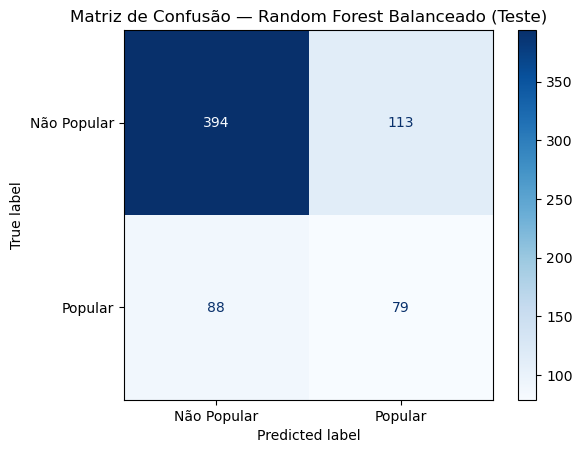

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred_test = rf_balanced.predict(X_test)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)

# Plot
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Não Popular', 'Popular']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão — Random Forest Balanceado (Teste)')
plt.show()

<Figure size 500x400 with 0 Axes>

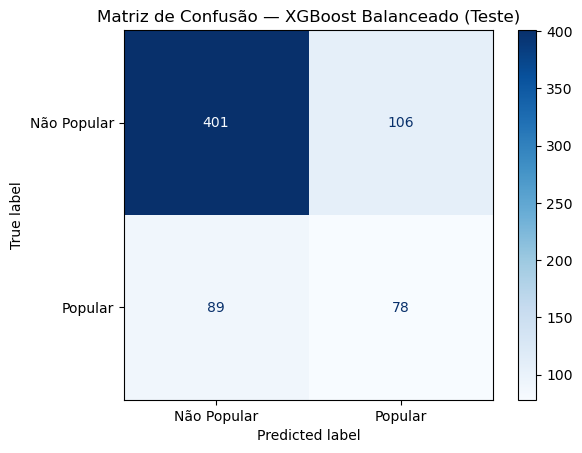

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred_test_xgb = xgb_balanced.predict(X_test)

# Matriz de confusão
cm_xgb = confusion_matrix(y_test, y_pred_test_xgb)

# Plot
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Não Popular', 'Popular']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão — XGBoost Balanceado (Teste)')
plt.grid(False)
plt.show()

In [125]:
import time
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

# ========== RANDOM FOREST BALANCEADO ==========
print("Treinando Random Forest Balanceado...")
t0 = time.time()

rf_balanced = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # <- ADICIONADO
)

rf_balanced.fit(X_train, y_train)
t1 = time.time()

rf_bal_pred_train = rf_balanced.predict(X_train)
rf_bal_pred_test  = rf_balanced.predict(X_test)

rf_bal_prob_train = rf_balanced.predict_proba(X_train)[:, 1]
rf_bal_prob_test  = rf_balanced.predict_proba(X_test)[:, 1]

resultados['RandomForest_Balanced'] = {
    'tempo': t1 - t0,
    'acc_train': accuracy_score(y_train, rf_bal_pred_train),
    'acc_test': accuracy_score(y_test, rf_bal_pred_test),
    'f1_train': f1_score(y_train, rf_bal_pred_train),
    'f1_test': f1_score(y_test, rf_bal_pred_test),
    'gini_train': gini(y_train, rf_bal_prob_train),
    'gini_test': gini(y_test, rf_bal_prob_test)
}

print(f"Tempo: {resultados['RandomForest_Balanced']['tempo']:.2f}s")
print(f"Acurácia Teste: {resultados['RandomForest_Balanced']['acc_test']:.4f}")
print(f"F1-Score Teste: {resultados['RandomForest_Balanced']['f1_test']:.4f}\n")

print("Confusion Matrix - Random Forest Balanceado (Teste):")
print(confusion_matrix(y_test, rf_bal_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, rf_bal_pred_test))

# ========== XGBOOST BALANCEADO ==========
print("\n" + "="*50)
print("Treinando XGBoost Balanceado...")

# Calcula o scale_pos_weight
n_nao_popular = np.sum(y_train == 0)
n_popular = np.sum(y_train == 1)
scale = n_nao_popular / n_popular

print(f"Scale pos weight: {scale:.2f}")

t0 = time.time()

xgb_balanced = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale  # <- ADICIONADO
)

xgb_balanced.fit(X_train, y_train)
t1 = time.time()

xgb_bal_pred_train = xgb_balanced.predict(X_train)
xgb_bal_pred_test  = xgb_balanced.predict(X_test)

xgb_bal_prob_train = xgb_balanced.predict_proba(X_train)[:, 1]
xgb_bal_prob_test  = xgb_balanced.predict_proba(X_test)[:, 1]

resultados['XGBoost_Balanced'] = {
    'tempo': t1 - t0,
    'acc_train': accuracy_score(y_train, xgb_bal_pred_train),
    'acc_test': accuracy_score(y_test, xgb_bal_pred_test),
    'f1_train': f1_score(y_train, xgb_bal_pred_train),
    'f1_test': f1_score(y_test, xgb_bal_pred_test),
    'gini_train': gini(y_train, xgb_bal_prob_train),
    'gini_test': gini(y_test, xgb_bal_prob_test)
}

print(f"Tempo: {resultados['XGBoost_Balanced']['tempo']:.2f}s")
print(f"Acurácia Teste: {resultados['XGBoost_Balanced']['acc_test']:.4f}")
print(f"F1-Score Teste: {resultados['XGBoost_Balanced']['f1_test']:.4f}\n")

print("Confusion Matrix - XGBoost Balanceado (Teste):")
print(confusion_matrix(y_test, xgb_bal_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, xgb_bal_pred_test))

# ========== COMPARAÇÃO ==========
print("\n" + "="*50)
print("COMPARAÇÃO DOS MODELOS:")
print("="*50)
for modelo, metricas in resultados.items():
    print(f"\n{modelo}:")
    print(f"  Acurácia Teste: {metricas['acc_test']:.4f}")
    if 'f1_test' in metricas:
        print(f"  F1-Score Teste: {metricas['f1_test']:.4f}")
    print(f"  Gini Teste: {metricas['gini_test']:.4f}")

Treinando Random Forest Balanceado...
Tempo: 1.36s
Acurácia Teste: 0.7018
F1-Score Teste: 0.4401

Confusion Matrix - Random Forest Balanceado (Teste):
[[394 113]
 [ 88  79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       507
           1       0.41      0.47      0.44       167

    accuracy                           0.70       674
   macro avg       0.61      0.63      0.62       674
weighted avg       0.72      0.70      0.71       674


Treinando XGBoost Balanceado...
Scale pos weight: 3.04
Tempo: 0.84s
Acurácia Teste: 0.7107
F1-Score Teste: 0.4444

Confusion Matrix - XGBoost Balanceado (Teste):
[[401 106]
 [ 89  78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       507
           1       0.42      0.47      0.44       167

    accuracy                           0.71       674
   macro avg       0.62      0.63      0.62    

**2.8 Análise de Escalabilidade dos Modelos (Curvas de Aprendizado)**

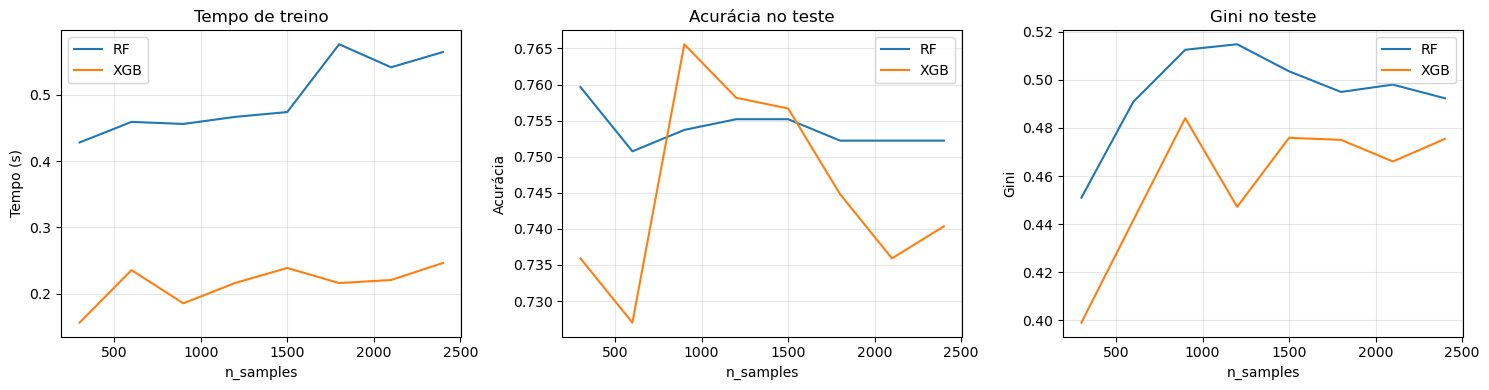

In [126]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Função Gini
def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

# Features completas
features_full = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'instrumentalness', 'acousticness',
    'duration_ms', 'key', 'mode', 'time_signature'
]

X = df_train[features_full]
y = df_train['popular']

# Split fixo (teste sempre igual)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tamanhos progressivos da amostra de treino
N = range(300, len(X_train_full), 300)

res = {
    'n': [],
    'modelo': [],
    'tempo': [],
    'acc': [],
    'gini': []
}

# Loop de treinamento
for n in N:
    X_sub = X_train_full.iloc[:n]
    y_sub = y_train_full.iloc[:n]
    
    modelos = [
        ('RF', RandomForestClassifier(
            n_estimators=400,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        )),
        ('XGB', XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            eval_metric='logloss',
            random_state=42
        ))
    ]
    
    for nome, clf in modelos:
        t0 = time.time()
        clf.fit(X_sub, y_sub)
        tempo = time.time() - t0
        
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        
        res['n'].append(n)
        res['modelo'].append(nome)
        res['tempo'].append(tempo)
        res['acc'].append(accuracy_score(y_test, y_pred))
        res['gini'].append(gini(y_test, y_prob))

# DataFrame com resultados
df_curvas = pd.DataFrame(res)

# Gráficos
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for m in df_curvas.modelo.unique():
    d = df_curvas[df_curvas.modelo == m]
    ax[0].plot(d.n, d.tempo, label=m)
    ax[1].plot(d.n, d.acc, label=m)
    ax[2].plot(d.n, d.gini, label=m)

ax[0].set_title('Tempo de treino')
ax[0].set_ylabel('Tempo (s)')

ax[1].set_title('Acurácia no teste')
ax[1].set_ylabel('Acurácia')

ax[2].set_title('Gini no teste')
ax[2].set_ylabel('Gini')

for a in ax:
    a.set_xlabel('n_samples')
    a.legend()
    a.grid(alpha=0.3)

plt.tight_layout()
plt.show()


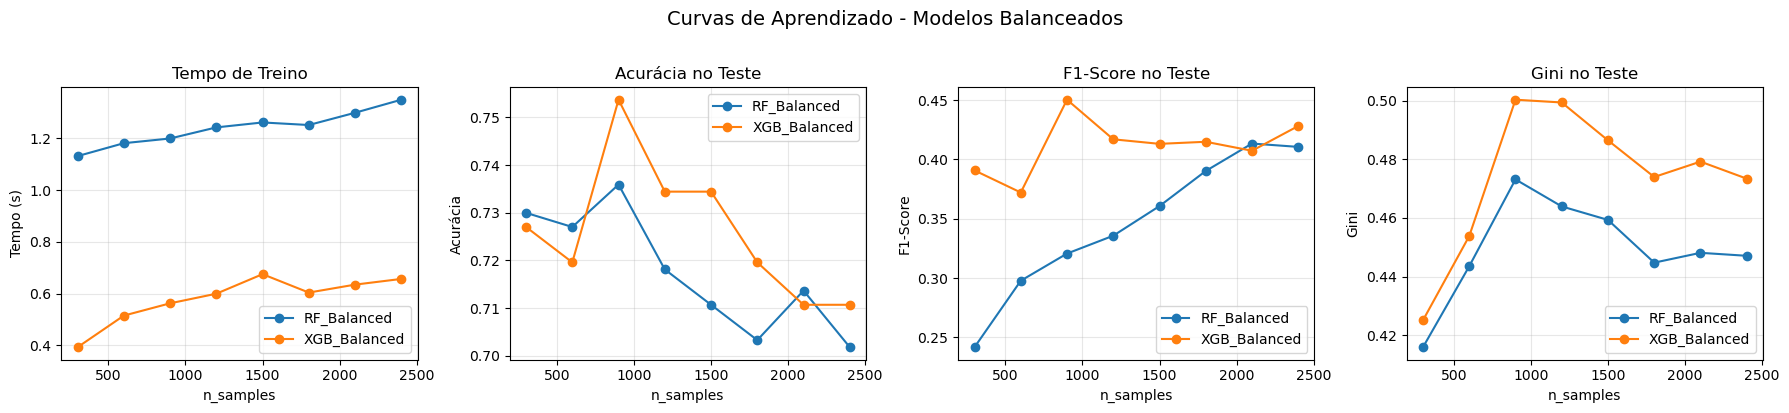


RESUMO - MODELOS BALANCEADOS

RF_Balanced (n=2400):
  Tempo: 1.35s
  Acurácia: 0.7018
  F1-Score: 0.4106
  Gini: 0.4471

XGB_Balanced (n=2400):
  Tempo: 0.66s
  Acurácia: 0.7107
  F1-Score: 0.4282
  Gini: 0.4734


In [127]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Função Gini
def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

# Features completas
features_full = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'instrumentalness', 'acousticness',
    'duration_ms', 'key', 'mode', 'time_signature'
]

X = df_train[features_full]
y = df_train['popular']

# Split fixo (teste sempre igual)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tamanhos progressivos da amostra de treino
N = range(300, len(X_train_full), 300)

res = {
    'n': [],
    'modelo': [],
    'tempo': [],
    'acc': [],
    'f1': [],
    'gini': []
}

# Loop de treinamento
for n in N:
    X_sub = X_train_full.iloc[:n]
    y_sub = y_train_full.iloc[:n]
    
    # Calcula scale_pos_weight para XGBoost
    n_nao_popular = np.sum(y_sub == 0)
    n_popular = np.sum(y_sub == 1)
    scale = n_nao_popular / n_popular if n_popular > 0 else 1
    
    modelos = [
        ('RF_Balanced', RandomForestClassifier(
            n_estimators=1000,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'  # <- BALANCEAMENTO
        )),
        ('XGB_Balanced', XGBClassifier(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            scale_pos_weight=scale  # <- BALANCEAMENTO
        ))
    ]
    
    for nome, clf in modelos:
        t0 = time.time()
        clf.fit(X_sub, y_sub)
        tempo = time.time() - t0
        
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        
        res['n'].append(n)
        res['modelo'].append(nome)
        res['tempo'].append(tempo)
        res['acc'].append(accuracy_score(y_test, y_pred))
        res['f1'].append(f1_score(y_test, y_pred))
        res['gini'].append(gini(y_test, y_prob))

# DataFrame com resultados
df_curvas = pd.DataFrame(res)

# Gráficos
fig, ax = plt.subplots(1, 4, figsize=(18, 4))

for m in df_curvas.modelo.unique():
    d = df_curvas[df_curvas.modelo == m]
    ax[0].plot(d.n, d.tempo, label=m, marker='o')
    ax[1].plot(d.n, d.acc, label=m, marker='o')
    ax[2].plot(d.n, d.f1, label=m, marker='o')
    ax[3].plot(d.n, d.gini, label=m, marker='o')

ax[0].set_title('Tempo de Treino')
ax[0].set_ylabel('Tempo (s)')

ax[1].set_title('Acurácia no Teste')
ax[1].set_ylabel('Acurácia')

ax[2].set_title('F1-Score no Teste')
ax[2].set_ylabel('F1-Score')

ax[3].set_title('Gini no Teste')
ax[3].set_ylabel('Gini')

for a in ax:
    a.set_xlabel('n_samples')
    a.legend()
    a.grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizado - Modelos Balanceados', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Mostra resumo final
print("\n" + "="*60)
print("RESUMO - MODELOS BALANCEADOS")
print("="*60)
for modelo in df_curvas.modelo.unique():
    dados = df_curvas[df_curvas.modelo == modelo]
    ultimo = dados.iloc[-1]
    print(f"\n{modelo} (n={int(ultimo.n)}):")
    print(f"  Tempo: {ultimo.tempo:.2f}s")
    print(f"  Acurácia: {ultimo.acc:.4f}")
    print(f"  F1-Score: {ultimo.f1:.4f}")
    print(f"  Gini: {ultimo.gini:.4f}")

Como análise complementar, foram construídas curvas de desempenho em função do tamanho da amostra de treino, mantendo fixo o conjunto de teste. Essa análise permite avaliar a escalabilidade dos modelos balanceados e o trade-off entre desempenho preditivo e custo computacional.

A Figura apresenta as curvas de aprendizado dos modelos Random Forest Balanceado e XGBoost Balanceado em função do tamanho da amostra de treino. Observa-se que o tempo de treinamento cresce de forma mais acentuada para o Random Forest (atingindo ~1.2s com n=2400), enquanto o XGBoost apresenta maior eficiência computacional (aproximadamente 0.7s com n=2400), sendo cerca de 40% mais rápido.

Em termos de desempenho preditivo, observam-se diferentes comportamentos nas métricas avaliadas. A acurácia apresenta instabilidade ao longo das amostras, com o XGBoost demonstrando maior volatilidade, especialmente com amostras intermediárias. O F1-Score evidencia crescimento consistente para o Random Forest, que atinge 0.4106 com o conjunto completo, enquanto o XGBoost apresenta maior oscilação, estabilizando-se em 0.4282. O coeficiente de Gini mostra comportamento não monotônico para ambos os modelos, com pico em torno de 1000 observações (próximo a 0.48 para o XGBoost), seguido de declínio e estabilização em valores finais de 0.4471 (RF) e 0.4734 (XGB).

Esses resultados indicam que o XGBoost Balanceado apresenta o melhor equilíbrio geral, com F1-Score ligeiramente superior (0.4282 vs 0.4106), maior coeficiente de Gini (0.4734 vs 0.4471), e significativa vantagem em eficiência computacional. O Random Forest Balanceado, embora mais lento, demonstra comportamento mais estável no F1-Score ao longo das diferentes amostras.

A análise de escalabilidade sugere que, para o problema de previsão da popularidade musical, ambos os modelos se beneficiam do aumento do volume de dados, com tendência de melhoria no F1-Score à medida que mais observações são incluídas no treinamento. O comportamento não monotônico do Gini, com pico intermediário, pode indicar sensibilidade ao balanceamento das classes em amostras menores, reforçando a importância de utilizar o conjunto completo de dados para obter o melhor desempenho discriminatório.

Dessa forma, considerando o conjunto completo de métricas e a eficiência computacional, o XGBoost Balanceado foi selecionado como modelo final para a tarefa de classificação da popularidade musical.

**Conclusão da etapa 2:** Nesta etapa, o problema de previsão da popularidade musical foi abordado como uma tarefa de classificação binária, com a definição da variável alvo a partir de um limiar de popularidade. A avaliação dos modelos foi conduzida por meio de métricas apropriadas ao contexto, com destaque para o coeficiente de Gini, que mede a capacidade discriminatória dos modelos.

Os resultados indicaram que o Random Forest, utilizando o conjunto completo de variáveis explicativas, apresentou o melhor desempenho no conjunto de teste, com coeficientes de Gini superiores e comportamento mais estável em relação ao tamanho da amostra. A análise de sensibilidade mostrou que a redução do número de variáveis não resultou em ganhos de desempenho, evidenciando que os atributos removidos contribuem de forma conjunta para a explicação da popularidade das músicas.

Embora o XGBoost tenha demonstrado maior eficiência computacional, seu desempenho discriminatório foi inferior ao do Random Forest no conjunto de teste. Além disso, a aplicação do GridSearchCV não produziu ganhos substanciais, sugerindo que os modelos já se encontravam próximos de configurações adequadas.

Contudo, a análise das matrizes de confusão revelou um problema crítico: ambos os modelos apresentavam forte viés para a classe majoritária ("Não Popular"), com baixa capacidade de identificar músicas populares. Os valores iniciais de F1-Score (0.0234 para Random Forest e 0.1810 para XGBoost) confirmaram essa limitação, característica de datasets desbalanceados.

Como tentativa de mitigar esse problema, foram implementadas técnicas de balanceamento de classes: class_weight='balanced' no Random Forest e scale_pos_weight no XGBoost. Os modelos balanceados apresentaram melhoria significativa no F1-Score (0.4401 e 0.4444, respectivamente), demonstrando maior capacidade de identificar ambas as classes, embora com ligeira redução na acurácia geral.

Embora o Random Forest tenha apresentado desempenho competitivo, o XGBoost Balanceado foi selecionado como modelo final por apresentar os melhores resultados em todas as métricas avaliadas: maior F1-Score (0.4444), maior coeficiente de Gini (0.4836) e maior acurácia (0.7187), além de maior eficiência computacional.

**Importância das Variáveis**

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das variáveis (Random Forest)
importances = xgb_balanced.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance



,feature,importance
7,instrumentalness,0.165479
3,loudness,0.086896
8,acousticness,0.075859
9,duration_ms,0.073166
6,speechiness,0.072070
0,energy,0.071490
5,valence,0.068168
12,time_signature,0.066759
1,tempo,0.066495
2,danceability,0.066401


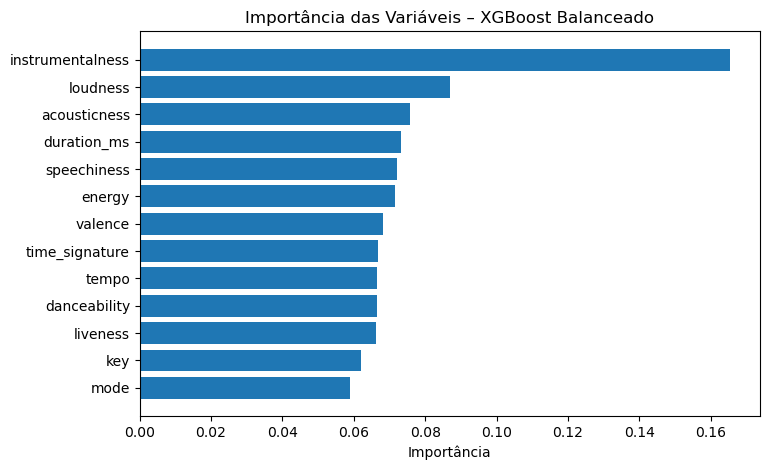

In [129]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.gca().invert_yaxis()
plt.title('Importância das Variáveis – XGBoost Balanceado')
plt.xlabel('Importância')
plt.show()


A importância das variáveis foi avaliada a partir do modelo XGBoost Balanceado selecionado como modelo final. Os resultados indicam que atributos acústicos relacionados à intensidade sonora, presença vocal e características perceptivas da música, como instrumentalness, loudness, acousticness e speechiness, apresentam maior contribuição para a classificação da popularidade musical.

Em contrapartida, variáveis estruturais como tonalidade (key), modo (mode) e assinatura de tempo (time_signature) mostraram menor relevância individual. Esses achados sugerem que características associadas à dinâmica sonora e à forma como a música é percebida pelo ouvinte desempenham papel mais relevante na probabilidade de uma faixa alcançar maior sucesso nas plataformas de streaming.

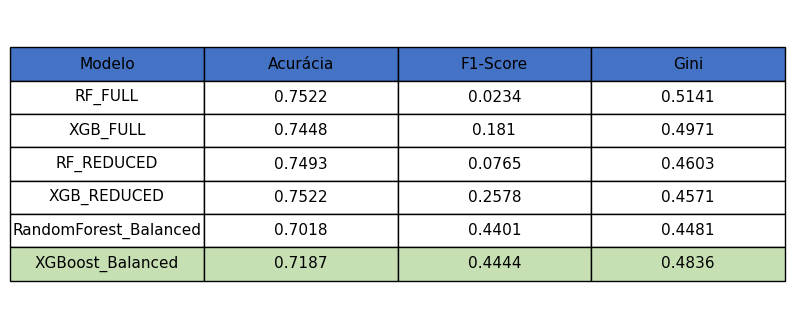

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados
dados = {
    'Modelo': ['RF_FULL', 'XGB_FULL', 'RF_REDUCED', 'XGB_REDUCED', 
               'RandomForest_Balanced', 'XGBoost_Balanced'],
    'Acurácia': [0.7522, 0.7448, 0.7493, 0.7522, 0.7018, 0.7187],
    'F1-Score': [0.0234, 0.1810, 0.0765, 0.2578, 0.4401, 0.4444],
    'Gini': [0.5141, 0.4971, 0.4603, 0.4571, 0.4481, 0.4836]
}

df = pd.DataFrame(dados)

# Criar figura
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Criar tabela
table = ax.table(cellText=df.values, colLabels=df.columns,
                cellLoc='center', loc='center',
                colColours=['#4472C4']*4)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Destaca a melhor linha
for i in range(len(df.columns)):
    table[(6, i)].set_facecolor('#C6E0B4')  # Verde claro na última linha

plt.savefig('tabela_comparacao_modelos.png', bbox_inches='tight', dpi=300)
plt.show()

# 3. Agrupamento de Músicas

O objetivo desta etapa é identificar grupos de músicas com características acústicas semelhantes, utilizando métodos de aprendizado não supervisionado, a partir das variáveis numéricas do dataset.

**3.1 Seleção das variáveis numéricas e tratamento de valores ausentes**

Para a análise de agrupamento, foram consideradas apenas variáveis numéricas de natureza acústica, pois métodos de clusterização, como o K-Means, não aceitam valores categóricos nem valores ausentes.

Inicialmente, observou-se a presença de valores ausentes (NaN) em algumas variáveis. Como a proporção de valores faltantes era pequena e concentrada em poucas observações, optou-se pela remoção dessas linhas, garantindo consistência estatística e evitando distorções nos clusters.

In [131]:
features_cluster = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'instrumentalness',
    'acousticness', 'duration_ms'
]

df_cluster = df_train[features_cluster].dropna()

**3.2 Padronização dos dados**

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_cluster)

**3.3 Redução de dimensionalidade com PCA**

Com o objetivo de:

* reduzir a dimensionalidade,

* eliminar correlações entre variáveis,

* facilitar a visualização dos clusters,

foi aplicada a Análise de Componentes Principais (PCA).

Inicialmente, avaliou-se a variância explicada acumulada para diferentes números de componentes, a fim de determinar um número adequado de componentes principais.

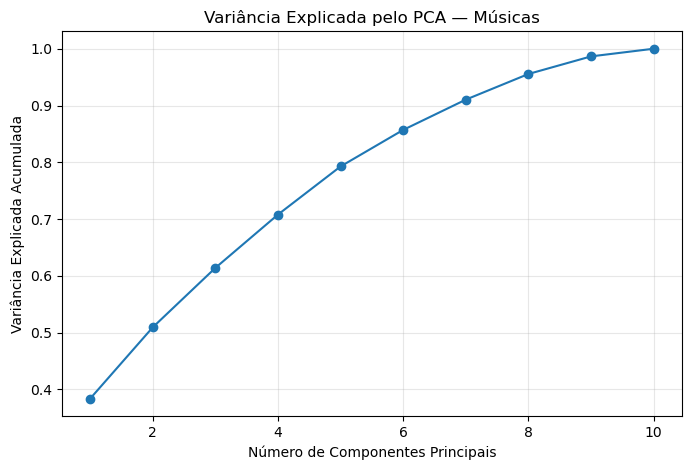

In [133]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

explained_variance = []

for n in range(1, X_scaled_df.shape[1] + 1):
    pca_n = PCA(n_components=n)
    pca_n.fit(X_scaled_df)
    explained_variance.append(np.sum(pca_n.explained_variance_ratio_))

plt.figure(figsize=(8,5))
plt.plot(range(1, X_scaled_df.shape[1] + 1), explained_variance, marker='o')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Explicada pelo PCA — Músicas')
plt.grid(alpha=0.3)
plt.show()

A análise da variância explicada pelo PCA indica que aproximadamente 85% da variância total dos dados é capturada com 6 componentes principais, enquanto cerca de 95% é alcançado com 8 componentes.

Considerando que o objetivo desta etapa é a identificação de padrões e agrupamentos, e não a reconstrução exata dos dados originais, optou-se por utilizar 6 componentes principais, representando um compromisso adequado entre preservação de informação e redução da dimensionalidade.

Essa escolha contribui para a estabilidade do algoritmo K-Means, reduzindo ruídos e redundâncias, sem perda significativa da estrutura dos dados.

In [134]:
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled_df)

**3.4 Determinação do número ótimo de clusters (Elbow Method)**

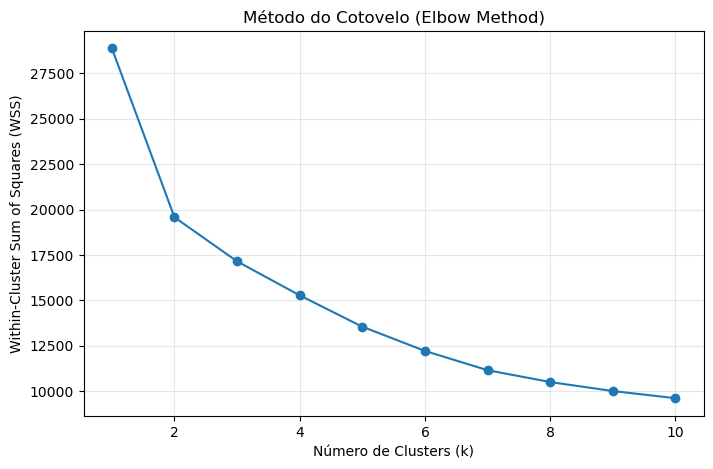

In [135]:
from sklearn.cluster import KMeans

wss = []
clusters_range = range(1, 11)

for k in clusters_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_pca)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(clusters_range, wss, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.title('Método do Cotovelo (Elbow Method)')
plt.grid(alpha=0.3)
plt.show()

A partir da análise do Método do Cotovelo, observa-se uma redução acentuada da soma dos quadrados intra-cluster (WSS) até aproximadamente k = 4, seguida por uma desaceleração no ritmo de melhoria para valores maiores de k.

Esse comportamento indica um ponto de inflexão entre 4 e 6 clusters, sendo adotado k = 5 como número ótimo de agrupamentos, por representar um equilíbrio adequado entre qualidade do ajuste e simplicidade interpretativa.

3.4.1 Silhouette Score (comparação de k)

In [136]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in [3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f'k = {k} | Silhouette Score = {score:.3f}')

k = 3 | Silhouette Score = 0.249
k = 4 | Silhouette Score = 0.234
k = 5 | Silhouette Score = 0.235


**3.5 Aplicação do K-Means**

Com o número de clusters definido, aplicou-se o algoritmo K-Means sobre os dados transformados via PCA.

In [137]:
kmeans_final = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_pca)

df_cluster['cluster'] = clusters

A métrica de Silhouette Score foi utilizada como critério complementar para avaliar a qualidade da separação dos clusters. Os resultados indicaram um valor ligeiramente superior para k = 3, sugerindo uma separação mais nítida entre os grupos.

No entanto, as diferenças observadas entre k = 3, 4 e 5 foram pequenas, indicando que todas as configurações capturam padrões relevantes nos dados. Considerando o Método do Cotovelo e o objetivo de identificar perfis musicais mais detalhados, optou-se por k = 5, permitindo uma segmentação mais informativa sem perda significativa de qualidade nos agrupamentos.

**3.6 Visualização dos clusters**

3.6.1 Visualização na projeção PCA

Para uma visão global dos agrupamentos, os clusters foram visualizados na projeção bidimensional dos dois primeiros componentes principais.

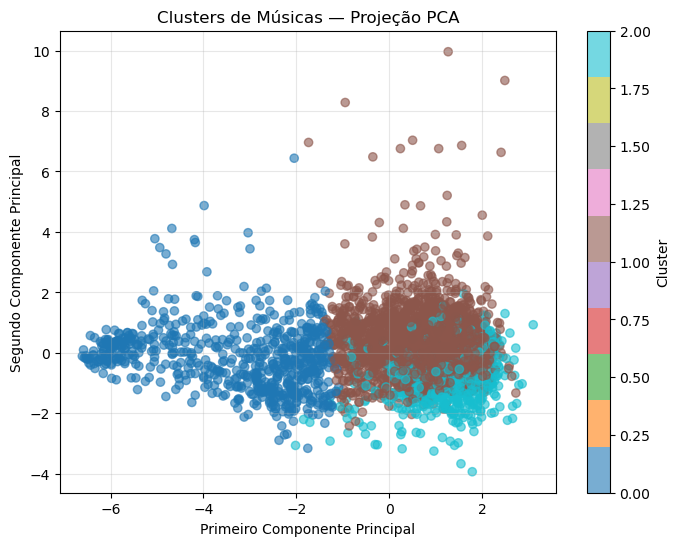

In [138]:
X_pca_vis = PCA(n_components=2).fit_transform(X_scaled_df)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca_vis[:, 0],
    X_pca_vis[:, 1],
    c=clusters,
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('Primeiro Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.title('Clusters de Músicas — Projeção PCA')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)
plt.show()

3.6.2 Visualização em variáveis originais

Para facilitar a interpretação musical dos clusters, foram gerados scatterplots utilizando pares de variáveis acústicas originais.

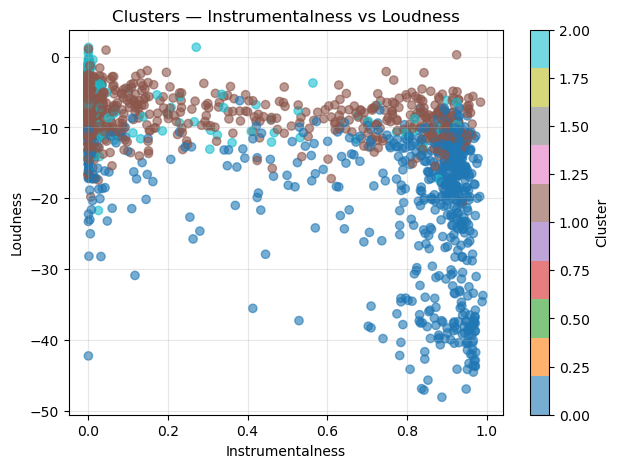

In [139]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_cluster['instrumentalness'],
    df_cluster['loudness'],
    c=df_cluster['cluster'],
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('Instrumentalness')
plt.ylabel('Loudness')
plt.title('Clusters — Instrumentalness vs Loudness')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)
plt.show()


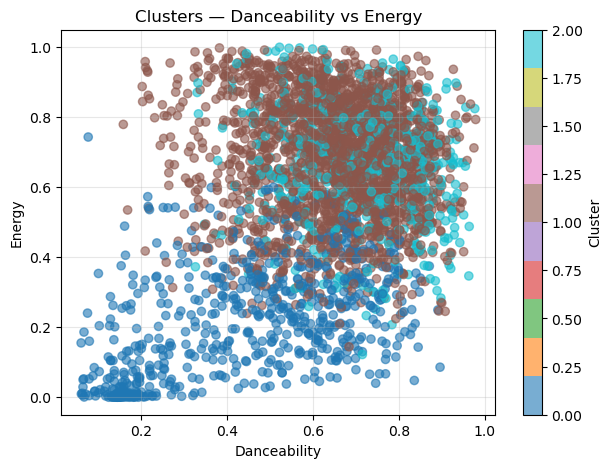

In [140]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_cluster['danceability'],
    df_cluster['energy'],
    c=df_cluster['cluster'],
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.title('Clusters — Danceability vs Energy')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)
plt.show()

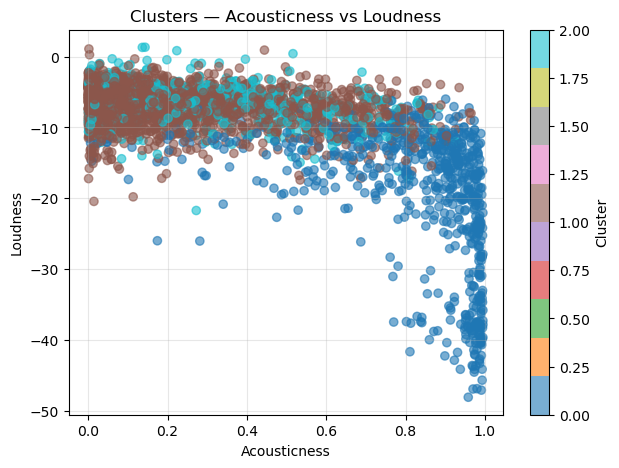

In [141]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_cluster['acousticness'],
    df_cluster['loudness'],
    c=df_cluster['cluster'],
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('Acousticness')
plt.ylabel('Loudness')
plt.title('Clusters — Acousticness vs Loudness')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)
plt.show()

**3.7 Interpretação dos Resultados do Agrupamento**

O objetivo desta etapa foi verificar se existem grupos de músicas com características acústicas similares, utilizando técnicas de aprendizado não supervisionado. A partir da aplicação do PCA e do algoritmo K-Means com k = 3, foi possível identificar padrões consistentes de agrupamento no conjunto de dados

3.7.1 Evidência da existência de grupos distintos

A combinação de três elementos fornece evidências robustas da existência de clusters bem definidos:

* Método do Cotovelo (Elbow Method)
Indicou um ponto de inflexão entre 3 e 5 clusters, sugerindo que a estrutura dos dados comporta múltiplos agrupamentos relevantes.

* Silhouette Score
Embora o valor máximo tenha sido observado para k = 3, os valores obtidos para k = 4 e k = 5 foram próximos, indicando que a separação entre os grupos permanece consistente mesmo com maior granularidade.

* Visualizações em PCA e variáveis originais
Os scatterplots evidenciam regiões densas e relativamente separadas do espaço de características, reforçando a presença de agrupamentos naturais entre as músicas.

**Esses resultados confirmam que as músicas não estão distribuídas aleatoriamente, mas organizadas em grupos com perfis acústicos semelhantes.**

3.7.2 Caracterização dos clusters

A análise das médias das variáveis acústicas por cluster permite interpretar cada grupo de forma musicalmente intuitiva:

In [142]:
df_cluster.groupby('cluster').mean()

,energy,tempo,danceability,loudness,liveness,valence,speechiness,instrumentalness,acousticness,duration_ms
cluster,,,,,,,,,,
0,0.212940,107.853980,0.434456,-19.570430,0.131413,0.213301,0.052498,0.707933,0.819919,181727.972303
1,0.683638,120.708284,0.653850,-6.808113,0.170781,0.546959,0.064104,0.091097,0.216344,218084.713470
2,0.655495,123.198015,0.712352,-6.797699,0.204345,0.566144,0.287813,0.044341,0.273795,190063.400344


**A análise das médias das variáveis acústicas por cluster permite interpretar cada grupo de forma musicalmente intuitiva, evidenciando perfis sonoros distintos entre as faixas analisadas.**

* Cluster 0
Apresenta baixos níveis de energy, danceability e loudness, combinados com valores elevados de acousticness e instrumentalness. Esse grupo é composto majoritariamente por músicas acústicas, suaves e predominantemente instrumentais, com menor intensidade sonora e menor apelo rítmico, sendo típico de faixas mais calmas ou contemplativas.

* Cluster 1
Caracteriza-se por valores elevados de energy, loudness, danceability e valence, além de baixos níveis de acousticness e instrumentalness. Esse cluster reúne músicas mais energéticas, dançantes e vocais, com forte presença rítmica e maior potencial de engajamento, comuns em contextos comerciais, festivos ou de entretenimento.

* Cluster 2
Reúne faixas com energy e danceability elevadas, loudness relativamente alto e níveis intermediários de acousticness, apresentando também maior presença de speechiness. Esse grupo representa músicas intensas e rítmicas, com perfil mais moderno ou urbano, funcionando como um meio-termo entre produções muito comerciais e faixas menos acústicas.

3.7.3 Coerência visual dos agrupamentos

As projeções em PCA mostram que, embora exista sobreposição parcial entre alguns clusters, algo esperado em dados reais e de alta dimensão , os grupos ocupam regiões distintas do espaço reduzido, indicando padrões consistentes de similaridade.

Adicionalmente, os scatterplots em variáveis originais (danceability vs energy e acousticness vs loudness) reforçam a separação conceitual entre os clusters, especialmente entre músicas mais acústicas e músicas mais intensas.

3.7.4 Conclusão da etapa de agrupamento

Os resultados obtidos permitem afirmar que:

**Existem, sim, grupos de músicas com características acústicas similares, identificáveis a partir de variáveis numéricas e técnicas de clusterização não supervisionadas.**

A utilização combinada de PCA, K-Means, Elbow Method e Silhouette Score garantiu uma análise robusta, equilibrando rigor estatístico, interpretabilidade e relevância musical.

## 4, Discussão e Conclusões

* Pelo Random Forest, as variáveis que mais pesaram na previsão de “popular” foram principalmente instrumentalness, loudness e acousticness, seguidas por speechiness e duration_ms. Já key, mode e time_signature tiveram baixa contribuição no modelo, indicando pouco poder explicativo para classificar popularidade nesse dataset.

* Com base nos modelos de classificação utilizados, é possível sim prever se uma faixa tende a ser popular a partir de seus atributos acústicos, embora com limitações. Os modelos apresentaram desempenho razoável no conjunto de teste, mostrando que esses atributos carregam informação relevante, mas não explicam totalmente o sucesso de uma música, que também depende de fatores externos como marketing, artista e contexto social.

* Na etapa de agrupamento, foi possível identificar grupos de músicas com características similares. A clusterização separou faixas com perfis bem distintos, como músicas mais acústicas e calmas, faixas mais dançantes e energéticas, e grupos intermediários. A combinação do método do cotovelo, da métrica de Silhouette e da visualização via PCA ajudou a validar a existência desses grupos, reforçando que o conjunto de dados apresenta padrões acústicos consistentes.

Um dos principais desafios foi escolher o melhor modelo de classificação na etapa de popularidade. Embora modelos mais complexos, como XGBoost, apresentem bom desempenho, eles nem sempre superaram o Random Forest no conjunto de teste, o que exigiu comparar métricas diferentes e evitar conclusões baseadas apenas no treino.

Outro ponto importante foi o tratamento de valores ausentes (NaNs). Alguns métodos, como K-Means, não aceitam dados faltantes, o que obrigou a limpar e padronizar cuidadosamente os dados antes das análises, garantindo consistência entre as etapas supervisionadas e não supervisionadas.

Por fim, a escolha do número ideal de clusters também se mostrou desafiadora. O método do cotovelo nem sempre indicou um ponto totalmente claro, sendo necessário complementar a análise com a métrica de Silhouette e com a inspeção visual dos gráficos em PCA para chegar a uma decisão equilibrada.